# Pipeline

DB -> DBT -> marts(cubes) -> metricflow -> LLM agents

https://github.com/datamindedbe/blog-tpcds-dbt-duckdb/tree/main

```
uv sync
```

In [ ]:
# # run this to generate index for values in the hierarchy yaml files

# import duckdb
# from src.hierarchy_duckdb import build_tree_with_stats
# from pathlib import Path
# proj_path = Path().resolve()
# data_path = proj_path / 'data'
# duckdb_conn = duckdb.connect(database=str(proj_path / 'tpcds/tpcds.db'))
# index_path = data_path / 'index'
# for yaml_path in (data_path / 'hierarchy').glob('*.yaml'):
#     tree = build_tree_with_stats(yaml_path, index_path, duckdb_conn)
#     with (data_path / 'hierarchy' / f"{yaml_path.stem}.json").open('w') as f:
#         f.write(tree.to_json())

In [1]:
# # run this only once to generate the TPC-DS data
import duckdb

con = duckdb.connect(database='./tpcds/tpcds.db')
con.execute('INSTALL tpcds;')
con.execute('LOAD tpcds;')
# con.execute("CALL dsdgen(sf = 1);")  # run only once generate data with scale factor 1 (1GB)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [1]:
from pathlib import Path
from src.schema_processor import display_graph

data_path = Path('./data')

In [2]:
display_graph(data_path)

Output()

In [4]:
from src.schema_processor import SchemaExplorer

explorer = SchemaExplorer(data_path)
attr_results = explorer.search_attribute('star', 'store_sales', 'd_fy_year')  # d_fy_year, s_store_id
attr_results

[{'dimension': 'date_dim',
  'attribute': 'd_fy_year',
  'path': [{'type': 'dimension', 'name': 'date_dim', 'label': 'date_dim'},
   {'type': 'level', 'name': 'd_date', 'label': 'Fiscal'},
   {'type': 'level', 'name': 'd_date', 'label': 'Date'},
   {'type': 'level', 'name': 'd_fy_week_seq', 'label': 'FY Week Seq'},
   {'type': 'level', 'name': 'd_fy_quarter_seq', 'label': 'FY Quarter Seq'},
   {'type': 'attribute', 'name': 'd_fy_year', 'label': 'FY Year'}],
  'stats': {'count': 73049,
   'null_count': 0,
   'distinct_count': 201,
   'min': 1900,
   'max': 2100,
   'range': [1900, 2100],
   'dtype': 'integer',
   'unique_values': {'type': 'bplustree',
    'values': '/home/jsjang/code/Agent4OLAP/data/index/date_dim__d_fy_year'}}}]

In [5]:
import random
from src.unique_index import UniqueIndex
path = './data/index/date_dim__d_fy_year'
idx = UniqueIndex(path, fast=False)

x = random.sample(list(iter(idx)), k=1)[0]
print("Search for:", x)
o = explorer.search_value('star', 'store_sales', 'd_fy_year', x)
print("Found:", o[0]['found'])
o

Search for: 2037
Found: True


[{'match': {'dimension': 'date_dim',
   'attribute': 'd_fy_year',
   'path': [{'type': 'dimension', 'name': 'date_dim', 'label': 'date_dim'},
    {'type': 'level', 'name': 'd_date', 'label': 'Fiscal'},
    {'type': 'level', 'name': 'd_date', 'label': 'Date'},
    {'type': 'level', 'name': 'd_fy_week_seq', 'label': 'FY Week Seq'},
    {'type': 'level', 'name': 'd_fy_quarter_seq', 'label': 'FY Quarter Seq'},
    {'type': 'attribute', 'name': 'd_fy_year', 'label': 'FY Year'}],
   'stats': {'count': 73049,
    'null_count': 0,
    'distinct_count': 201,
    'min': 1900,
    'max': 2100,
    'range': [1900, 2100],
    'dtype': 'integer',
    'unique_values': {'type': 'bplustree',
     'values': '/home/jsjang/code/Agent4OLAP/data/index/date_dim__d_fy_year'}}},
  'value': '2037',
  'found': True}]

----

## About the TPC-DS queries

In [2]:
from pathlib import Path
from collections import defaultdict
from src.schema_processor import SchemaExplorer
queries_path = Path('./queries/tpcds')

fact2queries = defaultdict(list)
queries2fact = defaultdict(set)
for qpath in queries_path.glob('*.sql'):
    with qpath.open() as f:
        sql = f.read()
    for fact in SchemaExplorer.tpcds_facts:
        if fact in sql.lower():
            queries2fact[qpath.stem].add(fact)

for query, facts in queries2fact.items():
    # set the number of the facts as key, more or equal to 4 make them one group
    if len(facts) >= 4:
        fact2queries['4+'].append(query)
    else:
        fact2queries[str(len(facts))].append(query)

In [8]:
for k, v in sorted(fact2queries.items(), key=lambda x: (int(x[0]) if x[0].isdigit() else 99)):
    print(f"{k}: {len(v)}")

1: 54
2: 17
3: 20
4+: 7


In [3]:
facts_queries_by_numbers: dict[str, dict[str, list[str]]] = defaultdict(dict)
for fact in SchemaExplorer.tpcds_facts:
    for number, queries in fact2queries.items():
        if facts_queries_by_numbers[fact].get(number) is None:
            facts_queries_by_numbers[fact][number] = []
        facts_queries_by_numbers[fact][number].extend(queries)


In [9]:
sorted(facts_queries_by_numbers['store_sales']['1'])[:5]

['query1', 'query12', 'query13', 'query15', 'query18']

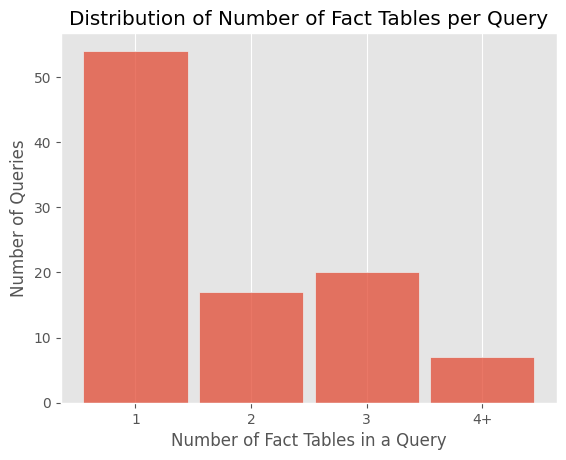

In [ ]:
# plot the distribution of number of fact tables per query
# make the number in the center of the bars
# if number is 4 or more, put it in 4+
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

fact_counts = [len(v) for v in queries2fact.values()]
fact_counts = [4 if x >= 4 else x for x in fact_counts]
fig, ax = plt.subplots()

sns.histplot(fact_counts, discrete=True, shrink=0.9, ax=ax)
ax.set_xlabel('Number of Fact Tables in a Query')
ax.set_ylabel('Number of Queries')
ax.set_title('Distribution of Number of Fact Tables per Query')
plt.xticks(ticks=[1, 2, 3, 4], labels=['1', '2', '3', '4+'])
plt.grid(axis='y')
plt.show()

## OLAP queries in Cube.dev

It is very different from what we thought. 

### What we thought:

```json
  {
    "operation": "slice",
    "dimension": "date",
    "filter": {
      "column": "d_year",
      "operator": "equals_to",
      "value": 1998
    }
  },
  {
    "operation": "slice",
    "dimension": "date",
    "filter": {
      "column": "d_qoy",
      "operator": "equals_to",
      "value": 1
    }
  },
  {
    "operation": "dice",
    "dimensions": ["customer_address", "catalog_sales"],
    "filters": [
      {
        "column": "ca_zip",
        "operator": "substring_in",
        "value": ["85669", "86197", "88274", "83405", "86475", "85392", "85460", "80348", "81792"],
        "substring_params": {
          "start": 1,
          "length": 5
        }
      },
      {
        "column": "ca_state",
        "operator": "in",
        "value": ["CA", "WA", "GA"]
      },
      {
        "column": "cs_sales_price",
        "operator": "greater_than",
        "value": 500
      }
    ],
    "logical_operator": "OR"
  },
  {
    "operation": "roll-up",
    "dimension": "customer_address",
    "level": "ca_zip",
    "aggregation": {
      "measure": "cs_sales_price",
      "function": "SUM"
    }
  },
  {
    "operation": "sort",
    "dimension": "customer_address",
    "column": "ca_zip",
    "order": "ascending"
  },
  {
    "operation": "limit",
    "value": 100
  }
```

UI API for **Query 15**

```json
{
  "measures": ["catalog_sales.cs_sales_price"],
  "dimensions": ["customer_address_billing.ca_zip"],
  "filters": [
    {
      "or": [
        {
          "member": "customer_address_billing.ca_zip",
          "operator": "startsWith",
          "values": ["85669","86197","88274","83405","86475","85392","85460","80348","81792"]
        },
        {
          "member": "customer_address_billing.ca_state",
          "operator": "equals",
          "values": ["CA","WA","GA"]
        },
        {
          "member": "catalog_sales.cs_sales_price_raw",
          "operator": "gt",
          "values": ["500"]
        }
      ]
    },
    { "member": "date_dim.d_year", "operator": "equals", "values": ["1998"] },
    { "member": "date_dim.d_qoy",  "operator": "equals", "values": ["1"] }
  ],
  "order": { "customer_address_billing.ca_zip": "asc" },
  "limit": 100
}
```